In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

In [3]:
# Generate synthetic dataset (if df is unavailable)
df, _ = make_blobs(n_samples=200, centers=4, cluster_std=1.5, random_state=42)
df = pd.DataFrame(df, columns=["Age", "Spending Score (1-15000)"])

In [4]:
df.columns

Index(['Age', 'Spending Score (1-15000)'], dtype='object')

In [5]:
df

,Age,Spending Score (1-15000)
0,7.438541,2.683919
1,-6.438815,10.247140
2,-8.856698,5.977641
3,-11.010454,5.212327
4,-7.763674,-5.605706
...,...,...
195,-8.371966,9.536557
196,7.469158,2.235036
197,-0.140378,10.165438
198,-7.587525,-5.246684


In [7]:
# Feature selection
X = df[["Age", "Spending Score (1-15000)"]]

In [8]:
# Compute Inertia for Different K Values
inertia = []
k_values = range(1, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)
    print(f"K={k}, Inertia={kmeans.inertia_:.2f}")

K=1, Inertia=13570.82
K=2, Inertia=6447.72
K=3, Inertia=1737.86
K=4, Inertia=813.76
K=5, Inertia=736.40
K=6, Inertia=644.70
K=7, Inertia=570.72
K=8, Inertia=510.08
K=9, Inertia=463.07
K=10, Inertia=407.07


Text(0.5, 1.0, 'Elbow Method: Finding the Optimal K')

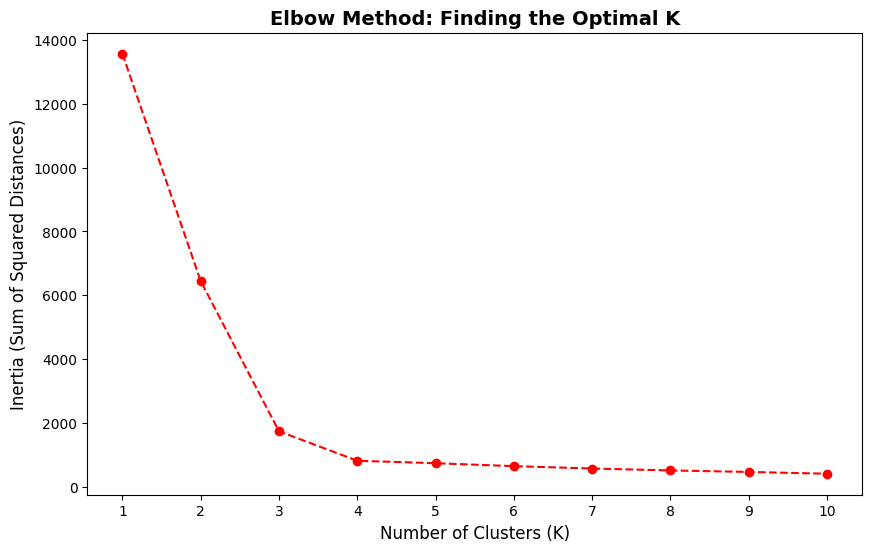

In [9]:
# Elbow Method Visualization
plt.figure(figsize=(10, 6))
plt.plot(k_values, inertia, marker="o", linestyle="--", color="red", label="Inertia")
plt.xticks(k_values)
plt.xlabel("Number of Clusters (K)", fontsize=12)
plt.ylabel("Inertia (Sum of Squared Distances)", fontsize=12)
plt.title("Elbow Method: Finding the Optimal K", fontsize=14, fontweight="bold")

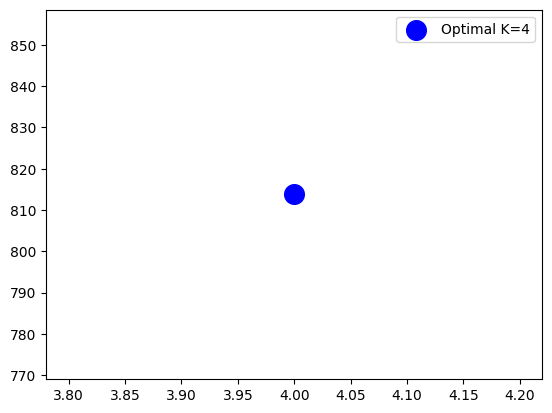

In [10]:
# Highlight the Elbow Point
optimal_k = 4  # Assume elbow at K=4 for our dataset
plt.scatter(optimal_k, inertia[optimal_k - 1], marker="o", color="blue", s=200, label=f"Optimal K={optimal_k}")
plt.legend()
plt.show()

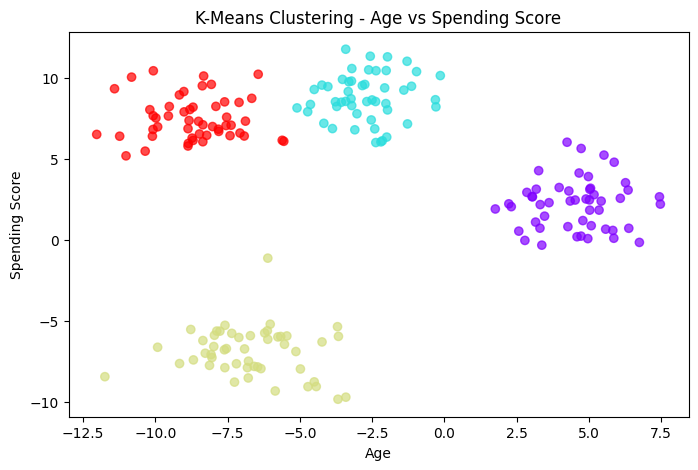

In [12]:
optimal_clusters = 4
kmeans = KMeans(n_clusters=optimal_clusters, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X)
plt.figure(figsize=(8, 5))
plt.scatter(df["Age"], df["Spending Score (1-15000)"], c=df["Cluster"], cmap="rainbow", alpha=0.7)
plt.xlabel("Age")
plt.ylabel("Spending Score")
plt.title("K-Means Clustering - Age vs Spending Score")
plt.show()

In [13]:
# steps   1️⃣         Visualizing Raw Data: Scatter Plot (Before Clustering)
Before applying K-Means, let’s visualize how the data looks without clustering.

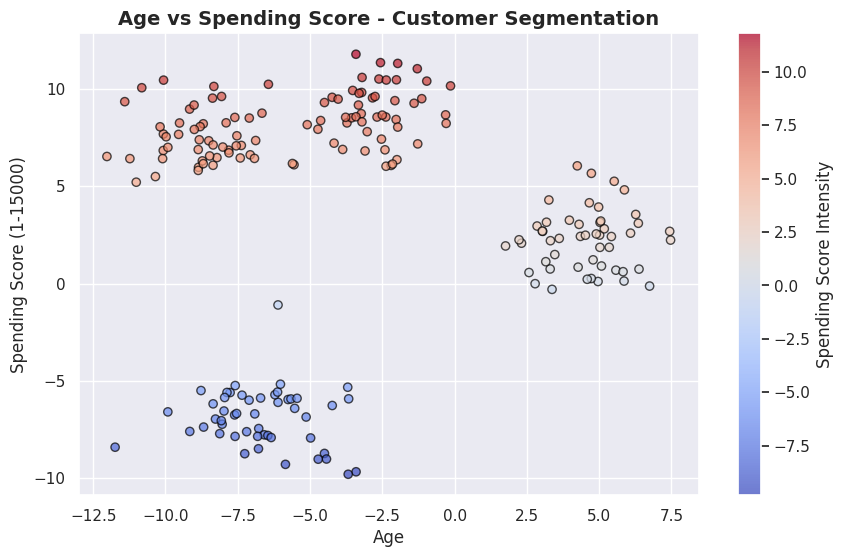

In [15]:
sns.set(style="darkgrid")             # Set style

# Scatter plot
plt.figure(figsize=(10, 6))
scatter = plt.scatter(df["Age"], df["Spending Score (1-15000)"],
                      c=df["Spending Score (1-15000)"], cmap="coolwarm",
                      alpha=0.7, edgecolors="black")

# Color bar
cbar = plt.colorbar(scatter)
cbar.set_label("Spending Score Intensity")

# Labels and title
plt.xlabel("Age", fontsize=12)
plt.ylabel("Spending Score (1-15000)", fontsize=12)
plt.title("Age vs Spending Score - Customer Segmentation", fontsize=14, fontweight="bold")
plt.show()

In [ ]:
# step2  2️⃣ Finding the Optimal Number of Clusters (Elbow Method)
The Elbow Method helps determine the best K (number of clusters) by calculating inertia (sum of squared distances from each point to its assigned centroid).


K=1, Inertia=13570.82
K=2, Inertia=6447.72
K=3, Inertia=1737.86
K=4, Inertia=813.76
K=5, Inertia=736.40
K=6, Inertia=644.70
K=7, Inertia=570.72
K=8, Inertia=510.08
K=9, Inertia=463.07
K=10, Inertia=407.07


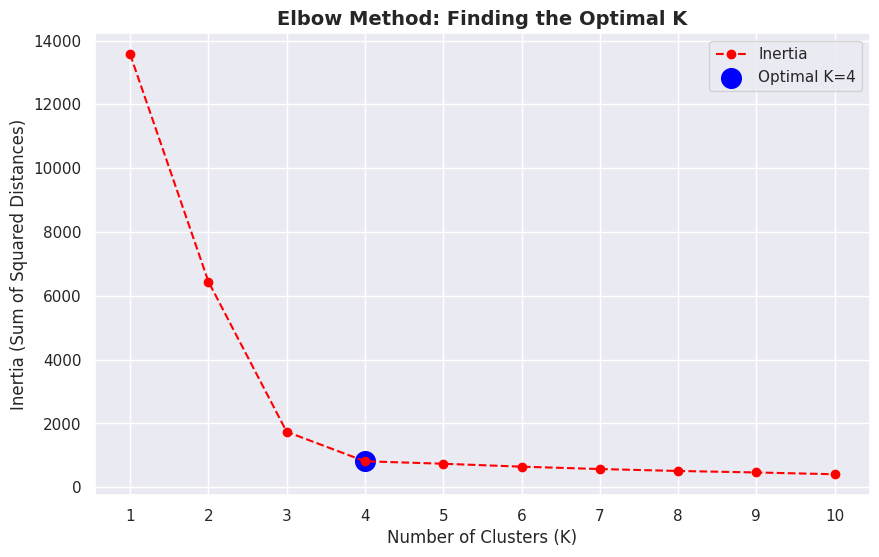

In [16]:
from sklearn.cluster import KMeans

# Select features
X = df[["Age", "Spending Score (1-15000)"]]

# Compute Inertia for Different K Values
inertia = []
k_values = range(1, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)
    print(f"K={k}, Inertia={kmeans.inertia_:.2f}")

# Plot Elbow Method
plt.figure(figsize=(10, 6))
plt.plot(k_values, inertia, marker="o", linestyle="--", color="red", label="Inertia")
plt.xticks(k_values)
plt.xlabel("Number of Clusters (K)", fontsize=12)
plt.ylabel("Inertia (Sum of Squared Distances)", fontsize=12)
plt.title("Elbow Method: Finding the Optimal K", fontsize=14, fontweight="bold")

# Highlight the Elbow Point
optimal_k = 4  # Assume elbow at K=4 for our dataset
plt.scatter(optimal_k, inertia[optimal_k - 1], marker="o", color="blue", s=200, label=f"Optimal K={optimal_k}")
plt.legend()
plt.show()

In [13]:
Insights:
Inertia decreases as K increases.
Elbow Point (K=4) is where the decrease in inertia slows, indicating the optimal number of clusters.
3️⃣ Clustering the Data with K-Means
Now, let’s apply K-Means using the optimal number of clusters.

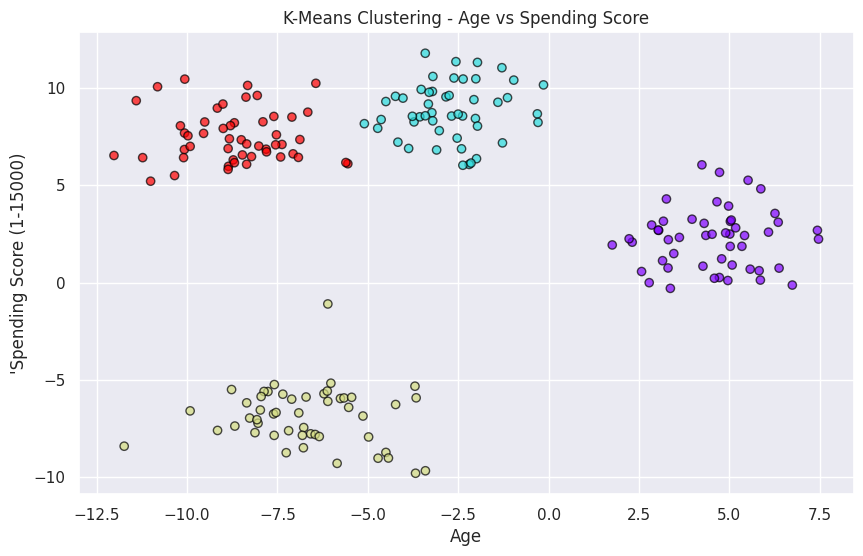

In [17]:
# Apply K-Means with Optimal K
optimal_clusters = 4
kmeans = KMeans(n_clusters=optimal_clusters, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X)

# Visualizing the Clusters
plt.figure(figsize=(10, 6))
plt.scatter(df["Age"], df["Spending Score (1-15000)"], c=df["Cluster"], cmap="rainbow", alpha=0.7, edgecolors="black")
plt.xlabel("Age")
plt.ylabel("'Spending Score (1-15000)")
plt.title("K-Means Clustering - Age vs Spending Score")
plt.show()

In [ ]:
# THE END

In [ ]:
Interpretation:
Now we can see 4 distinct groups of customers based on age and spending behavior.
The clusters help identify different customer behaviors (e.g., high spenders, low spenders, young vs. older customers).

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

In [25]:
# 🔹 Load dataset (if available)
try:
    df = pd.read_csv("customers.csv")  # Load real dataset
except:
    # Generate synthetic dataset (if file not found)
    df, _ = make_blobs(n_samples=200, centers=4, cluster_std=1.5, random_state=42)
    df = pd.DataFrame(df, columns=["Age", "Spending Score (1-15000)"])

In [26]:
# 🔹 Feature Selection
X = df[["Age", "Spending Score (1-15000)"]]

In [27]:
# 🔹 Apply K-Means with Optimal Clusters (Assumed K=4 from elbow method)
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X)

In [28]:
# 🔹 Define Cluster Labels (Based on Spending Score & Age)
labels = {
    0: "High Spenders (Young)",
    1: "Low Spenders (Older)",
    2: "Moderate Spenders",
    3: "High Spenders (Older)"
}

In [30]:
# 🔹 Assign readable labels
df["Segment"] = df["Cluster"].map(labels)

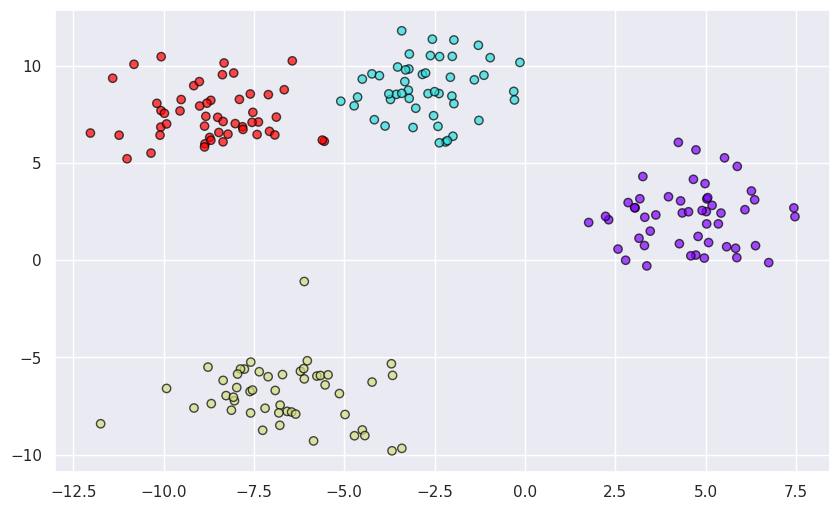

In [32]:
# 🔹 Plot Clusters with Labels
plt.figure(figsize=(10, 6))
scatter = plt.scatter(df["Age"], df["Spending Score (1-15000)"],
                      c=df["Cluster"], cmap="rainbow", alpha=0.7, edgecolors="black")

/tmp/ipython-input-555080882.py:2: UserWarning: Adding colorbar to a different Figure <Figure size 1000x600 with 6 Axes> than <Figure size 640x480 with 0 Axes> which fig.colorbar is called on.
  cbar = plt.colorbar(scatter)


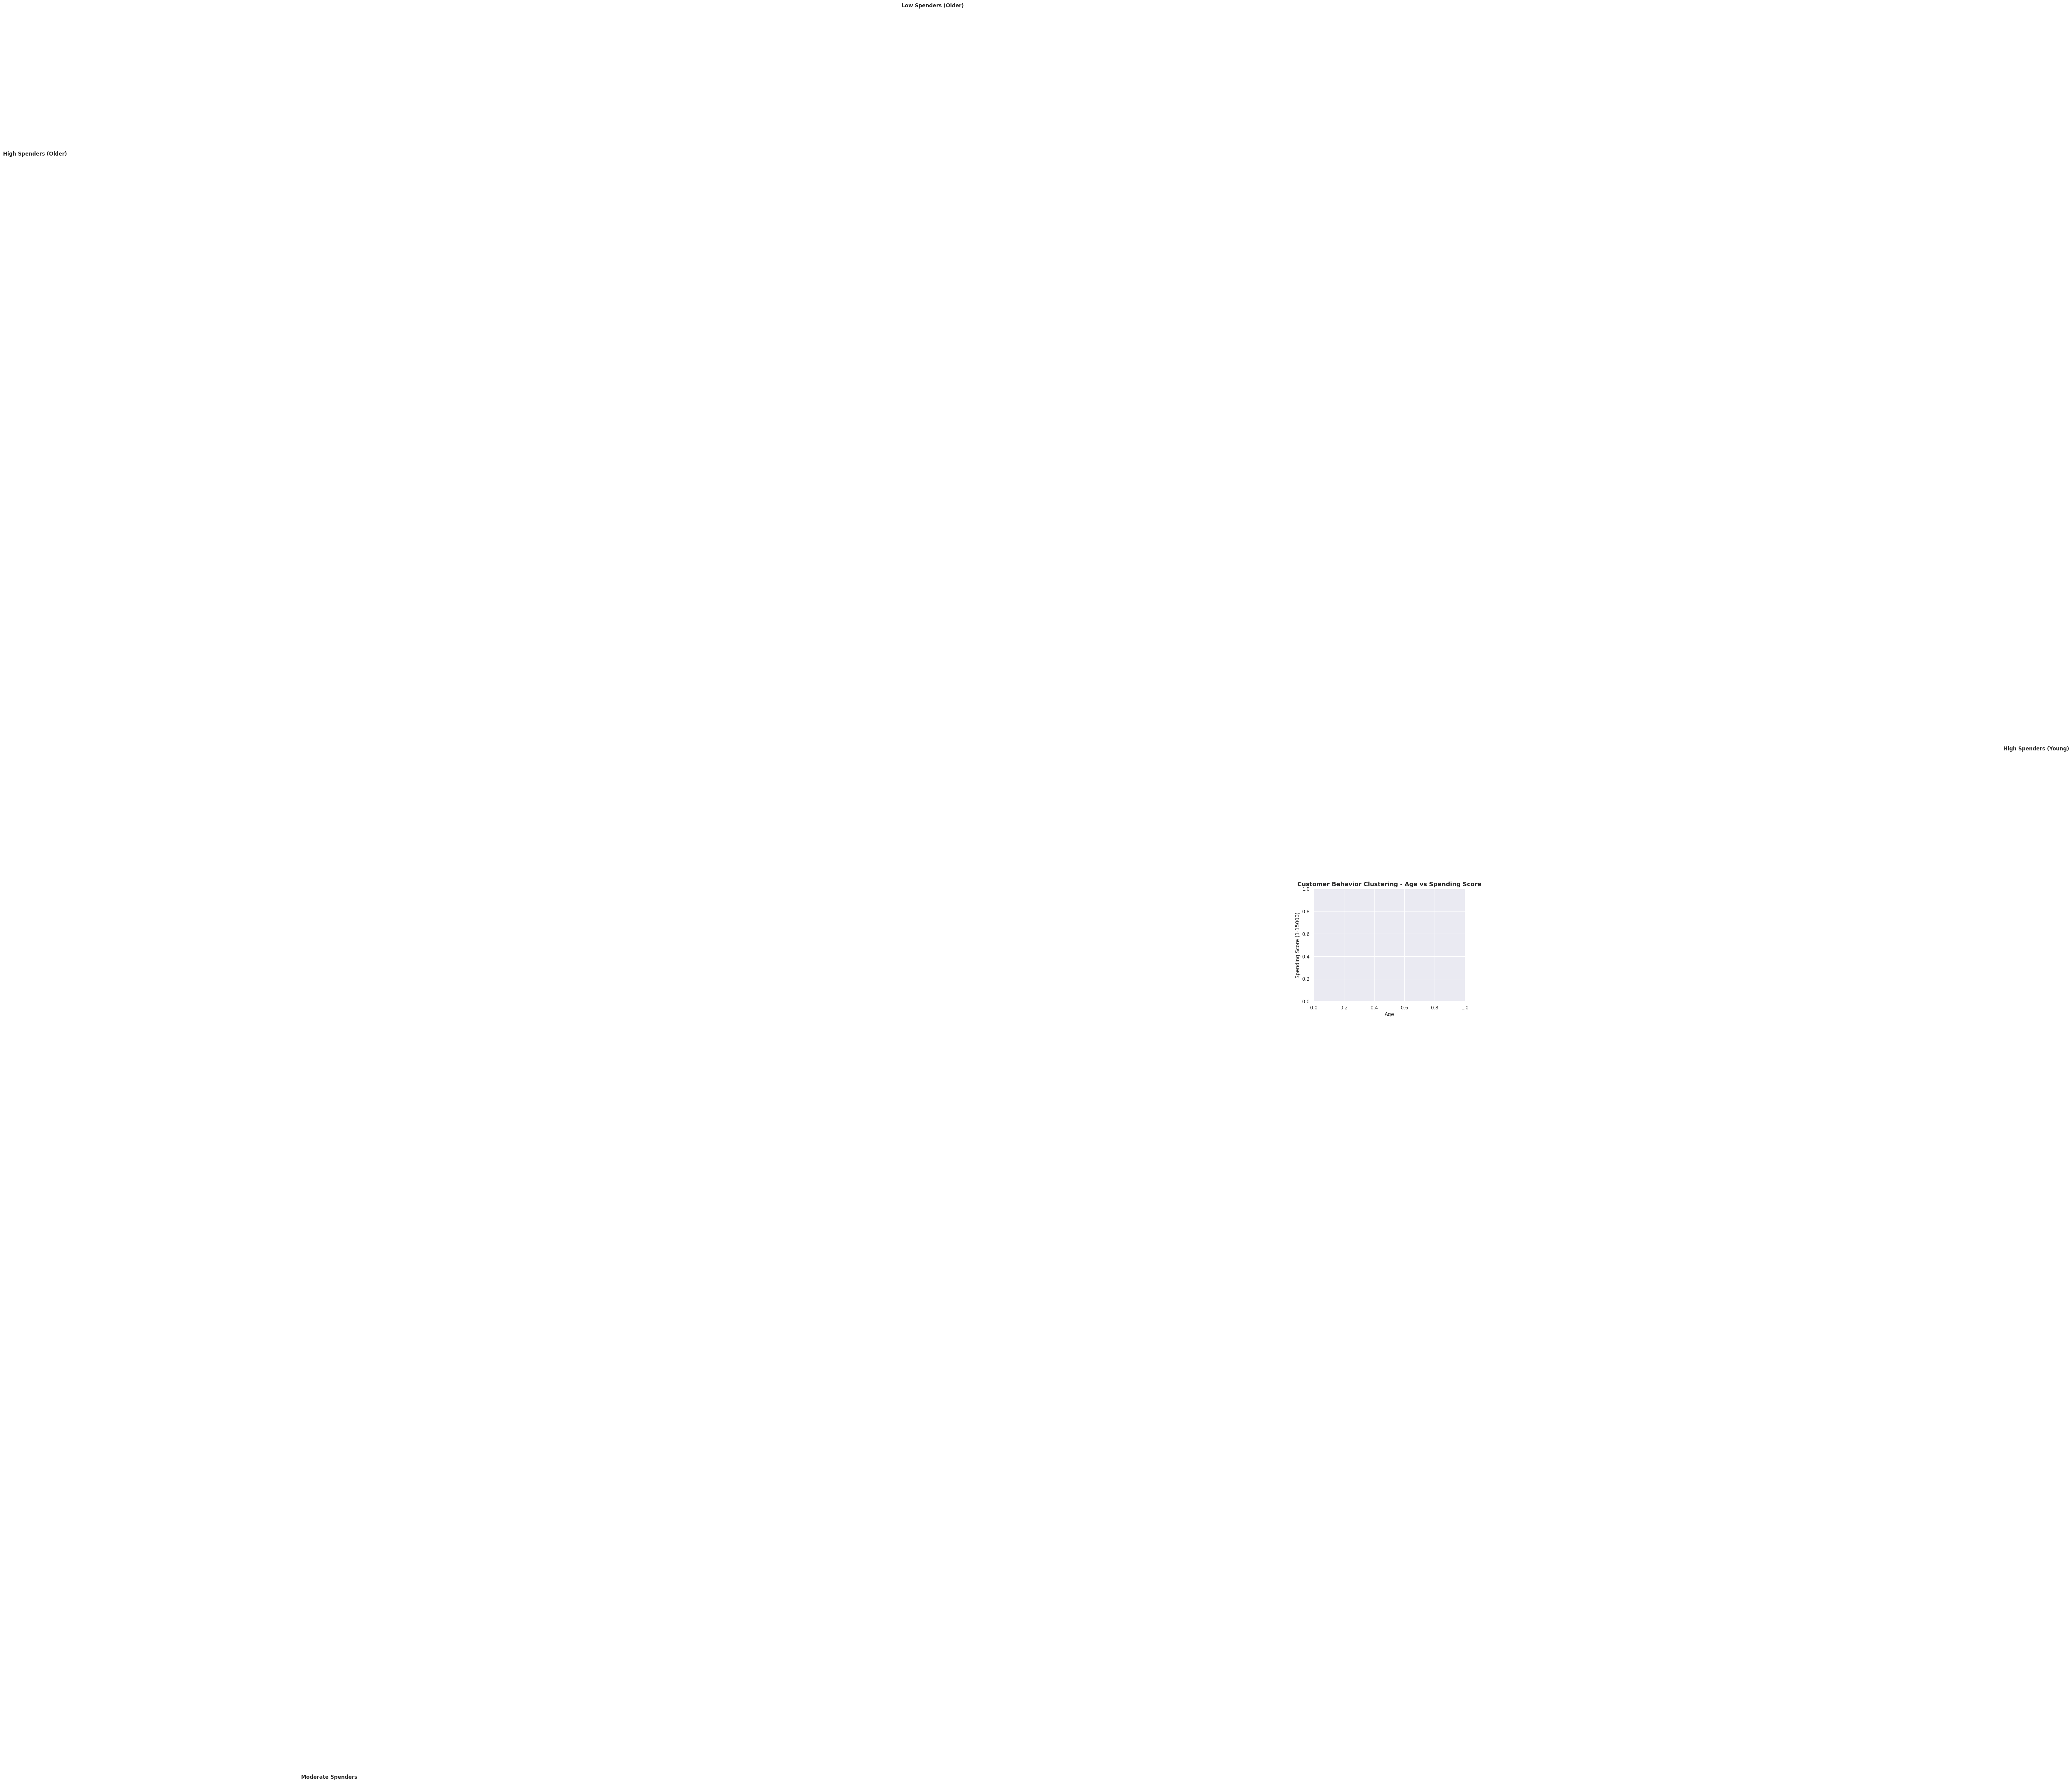

In [39]:
# Add color legend
cbar = plt.colorbar(scatter)
cbar.set_label("Cluster Group")

# Labeling clusters on the graph
for cluster, label in labels.items():
    cluster_data = df[df["Cluster"] == cluster]
    center_x, center_y = cluster_data["Age"].mean(), cluster_data["Spending Score (1-15000)"].mean()
    plt.text(center_x, center_y, label, fontsize=12, fontweight="bold", bbox=dict(facecolor="white", alpha=0.6))
# Labels and title
plt.xlabel("Age", fontsize=12)
plt.ylabel("Spending Score (1-15000)", fontsize=12)
plt.title("Customer Behavior Clustering - Age vs Spending Score", fontsize=14, fontweight="bold")
plt.show()


In [37]:
# 🔹 Display Cluster Data
print("📊 Customer Clustering Results:")
print(df.groupby("Segment").size().reset_index(name="Count"))

📊 Customer Clustering Results:
                 Segment  Count
0  High Spenders (Older)     51
1  High Spenders (Young)     50
2   Low Spenders (Older)     49
3      Moderate Spenders     50


In [17]:
# the end